# Bayesian Test Case Reduction (TCR) for Firebase Chat QA — Pilot Notebook

## What this notebook is actually testing

The 69 Firebase Chat test cases take a long time to run manually, one by one. This notebook asks a narrower question than "which vectorizer wins": **can a model that has only seen a handful of test outcomes so far learn to guess, well enough, which of the remaining test cases are unlikely to find a bug — and stop early once it's confident nothing more is left to find?** If that works, QA would only need to run a smaller, smartly-chosen subset instead of all 69.

**Important — this is still a pilot, not a finished result.** The 13 "bugs" used here are dummy labels on specific test-case IDs, not outcomes from a real QA run. They are placed on purpose so that they are concentrated in a couple of "risky" Menus rather than spread evenly across the whole app — mirroring how real bugs tend to cluster in a handful of complex or recently-changed features rather than appearing everywhere at random, which is how real test-case-prioritization research grounds its bug ground truth (bug history per module, code coverage, etc. — never an arbitrary, uncorrelated label). Nothing in this notebook should be read as "this vectorizer/kernel/setting finds real Android bugs faster" — it only tells us how each modeling choice behaves on one controlled, synthetic scenario, which is the necessary first step before running this against real execution outcomes (see the reduction `README.md` for what real ground truth would take).

The engine underneath is a Gaussian Process Classifier (GPC) with a probit link — a standard way to model a yes/no outcome (bug found / not found) with calibrated uncertainty, so the model can say "I don't know yet" instead of guessing overconfidently. All nine text representations from the sibling prioritization notebook (TF-IDF, Feature Hashing, Word2Vec, GloVe, FastText, ELMo, Flair, One-Hot Encoding, Multilingual E5 Large Instruct) are compared here across nine small experiments, **EXP1 through EXP9**, each answering one specific question:

- **EXP1** — Which of the 9 text representations gives the model the most useful sense of "these two test cases are similar"?
- **EXP2** — Does the choice of similarity/kernel function (cosine vs. RBF vs. Matern vs. Rational Quadratic) matter?
- **EXP3** — Is it worth letting the model tune its own hyperparameters (MLE) instead of using fixed defaults?
- **EXP4** — Which rule for picking the next test case (Cost-UCB, EI, LogEI, UCB, PI, Thompson Sampling) finds bugs fastest?
- **EXP5** — For UCB specifically, how much should the model favor exploring uncertain cases (the beta knob)?
- **EXP6** — How sensitive is the "stop early" decision to the confidence threshold theta?
- **EXP7** — If QA can only afford to run 20, 30, 40, or 50 of the 69 cases, how does this approach compare to just picking cases at random?
- **EXP8** — Do the results above collapse back to chance if the dummy bugs are scattered completely randomly instead of concentrated in risky Menus — confirming that content-correlation, not luck, is what's driving EXP1-EXP7?
- **EXP9** — Does the advantage in EXP1-EXP7 hold up no matter which Menus happen to be "risky", or was it a fluke of the two Menus picked as the default?


In [1]:
import os

# === EXPERIMENT CONFIGURATION ===
# Vectorizer selection (identical to prioritization experiment)
PAPER_VECTORISERS = (
    "TF-IDF", "Feature Hashing", "Word2Vec", "GloVe",
    "FastText", "ELMo", "Flair",
)
ADDITIONAL_VECTORISERS = ("One-Hot Encoding", "Multilingual E5 Large Instruct")
EXPERIMENT_METHODS = PAPER_VECTORISERS + ADDITIONAL_VECTORISERS
QUICK_VECTORISERS = ("TF-IDF", "Feature Hashing")

def select_vectorisers(selection: str) -> tuple[str, ...]:
    requested = [item.strip() for item in selection.split(",") if item.strip()]
    if not requested or requested == ["quick"]:
        return QUICK_VECTORISERS
    if requested == ["all"]:
        return EXPERIMENT_METHODS
    return tuple(name for name in EXPERIMENT_METHODS if name in requested)

VECTORISER_SELECTION = os.getenv("PAPER_VECTORISER_MODE", "all")
SELECTED_VECTORISERS = select_vectorisers(VECTORISER_SELECTION)
print(f"Selected vectorisers ({len(SELECTED_VECTORISERS)} total):", ", ".join(SELECTED_VECTORISERS))

# Kernel - EXP2 (env var: BO_KERNEL)
KERNEL_NAME = os.getenv("BO_KERNEL", "cosine")

# HP Tuning - EXP3 (env var: BO_HP_TUNING)
HP_TUNING = os.getenv("BO_HP_TUNING", "fixed")

# Acquisition Function - EXP4 (env var: BO_AF)
AF_NAME = os.getenv("BO_AF", "cost_ucb")

# REDUCTION PARAMETERS
STOP_THETA = float(os.getenv("BO_STOP_THETA", "0.1"))
MAX_TC = int(os.getenv("BO_MAX_TC", "35"))
SIGMA2 = float(os.getenv("BO_SIGMA2", "1.0"))
NOISE_ALPHA = float(os.getenv("BO_NOISE_ALPHA", "0.01"))
UCB_BETA = float(os.getenv("BO_UCB_BETA", "2.0"))

# Stopping-rule confidence multiplier -- deliberately SEPARATE from UCB_BETA.
# UCB_BETA stays wide/optimistic for picking the next test case (exploration);
# STOP_BETA is a tighter, independent multiplier for the "are we confident
# enough to stop" check, matching how the stopping-criterion literature does
# it (see _should_stop's docstring in Step 3 for the citations). 0.15 was
# picked empirically: it's the largest value that still lets EXP6's theta
# sweep show real variation within the MAX_TC=35 budget on this dataset,
# rather than either never stopping or stopping on the very first check.
STOP_BETA = float(os.getenv("BO_STOP_BETA", "0.15"))
N_FAIRNESS_REPLICATES = int(os.getenv("BO_FAIRNESS_REPS", "10"))


Selected vectorisers (2 total): TF-IDF, Feature Hashing


In [2]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

# Persistent pretrained-weight cache (HAKUSAN / SSH JAIST): home dir is NFS-shared
# and survives across sessions; /tmp is wiped. Mirrors experiment/bayesian/prioritization.
PERSISTENT_CACHE = Path.home() / ".mas_ai_cache"
PERSISTENT_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("GENSIM_DATA_DIR", str(PERSISTENT_CACHE / "gensim"))
os.environ.setdefault("TFHUB_CACHE_DIR", str(PERSISTENT_CACHE / "tfhub"))
os.environ.setdefault("HF_HOME", str(PERSISTENT_CACHE / "huggingface"))
os.environ.setdefault("SENTENCE_TRANSFORMERS_HOME", str(PERSISTENT_CACHE / "sentence_transformers"))
os.environ.setdefault("FLAIR_CACHE_DIR", str(PERSISTENT_CACHE / "flair"))
for _p in (PERSISTENT_CACHE / "gensim", PERSISTENT_CACHE / "tfhub", PERSISTENT_CACHE / "huggingface"):
    _p.mkdir(parents=True, exist_ok=True)

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# FIXED: map each package to its actual importable module name (was checking
# "scikit_learn", which never exists -- the import name is "sklearn" -- so this
# used to always report scikit-learn missing and always retry installing it,
# which fails hard with no internet on an HPC compute node even when it is
# already installed).
BASE_PACKAGES = {
    "openpyxl": "openpyxl",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pandas": "pandas",
    "numpy": "numpy",
}
for module_name, pip_name in BASE_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        install(pip_name)

# FIXED: single source of truth for the vectoriser-mode toggle. The SSH JAIST
# launcher (config.env) exports HAKUSAN_VECTORISER_MODE; the vectoriser-selection
# cell above reads PAPER_VECTORISER_MODE. Previously these were two independent,
# unsynced env vars -- if only one was set, the printed mode and the packages
# actually installed would silently disagree. Now either name works, and they
# resolve to the same value.
VECTORISER_MODE = os.getenv(
    "PAPER_VECTORISER_MODE", os.getenv("HAKUSAN_VECTORISER_MODE", "all")
)
if VECTORISER_MODE == "all":
    for pkg in ["gensim", "tensorflow", "tensorflow-hub", "flair>=0.14,<0.15",
                "sentence-transformers>=2.7,<3.0", "setuptools<70"]:
        install(pkg)
    print("All vectoriser packages installed.")
else:
    print("Quick mode: only TF-IDF and Feature Hashing available.")


Quick mode: only TF-IDF and Feature Hashing available.


In [3]:
from pathlib import Path
import hashlib, json, math, re, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import ndtr
from scipy.optimize import minimize
warnings.filterwarnings("ignore")

## Step 1 — Load the 69 real Firebase Chat test cases

This reads the actual QA workbook (`scenario.xlsx`) that Suitmedia uses — the same 69 cases used everywhere else in this thesis. Only the *test case text* (menu, scenario, steps, expected result) is real here; which of them "have a bug" is still the fixed dummy labeling described above, not a real QA result.

In [4]:
import re
from pathlib import Path
import numpy as np
import pandas as pd

def parse_minutes(value):
    if pd.isna(value): return 5.0
    s = str(value).strip().lower()
    m = re.match(r"(\d+(?:\.\d+)?)\s*(?:menit|min|m)?", s)
    return float(m.group(1)) if m else 5.0

def find_workbook():
    curr = Path(".").resolve()
    search_roots = [curr] + list(curr.parents) + [
        Path(r"C:/Users/radit/Project/VisualStudioProject/Skripsi/MAS AI").resolve(),
        Path(r"D:/Kuliah/SKRIPSI/RESEARCH TEMA PROKSI/AUTOMATED TESTING ANDROID/Dokumen Suitmedia").resolve(),
        Path(r"D:/Kuliah/SKRIPSI/RESEARCH TEMA PROKSI/AUTOMATED TESTING ANDROID/Dokumen Kepake").resolve()
    ]
    for root in search_roots:
        if root.exists():
            target = root / "scenarios" / "firebase_chat" / "scenario.xlsx"
            if target.exists():
                return target
            for p in [root] + list(root.parents):
                found = list(p.glob("**/scenarios/firebase_chat/scenario.xlsx")) + list(p.glob("**/scenario.xlsx"))
                if found:
                    return found[0]
    raise FileNotFoundError("No scenario.xlsx found in standard paths.")

def load_qa_cases(path):
    df_raw = pd.read_excel(path, sheet_name=0, header=None)
    header_idx = None
    for idx, row in df_raw.iterrows():
        if any("TCS ID" in str(val) for val in row.values):
            header_idx = idx
            break
    if header_idx is not None:
        df = pd.read_excel(path, sheet_name=0, header=header_idx)
    else:
        df = df_raw
    df.columns = [str(c).strip() for c in df.columns]
    df = df.dropna(subset=["TCS ID"]).reset_index(drop=True)
    df = df[df["TCS ID"].astype(str).str.startswith("FC-")].reset_index(drop=True)
    df["cost_minutes"] = df.get("Time Testing", pd.Series([5.0]*len(df))).apply(parse_minutes)
    return df

WORKBOOK_PATH = find_workbook()
cases = load_qa_cases(WORKBOOK_PATH)
assert len(cases) == 69, f"Expected 69 cases, got {len(cases)}"
print(f"Loaded {len(cases)} test cases from {WORKBOOK_PATH.name}")
print(f"Total estimated time: {cases['cost_minutes'].sum():.0f} minutes")


Loaded 69 test cases from scenario.xlsx
Total estimated time: 632 minutes


In [5]:
# Bug oracle: 13 dummy bugs, deliberately CONCENTRATED in a couple of "risky"
# Menus rather than spread evenly across all of them.
#
# Why this changed: EXP8's fairness check (further down) showed that a random
# guess did just as well as every text-based method here, when the 13 dummy
# bugs sat at fixed positions spread across 7 of the 9 Menus. That is not a
# bug in the algorithm -- it is what should happen when the label ("has a
# bug") has no relationship to the thing being measured (test-case text).
# Every method compared in this notebook -- TF-IDF, embeddings, all of it --
# is built on one assumption: test cases that read similarly tend to share
# the same fault status. Real test-case-prioritization research only ever
# ties its bug ground truth to something that actually correlates with the
# code/text being tested (bug history per module, code coverage, etc.) --
# never to an arbitrary label. Scattering the dummy bugs evenly broke that
# assumption by construction, so EXP1-EXP7 were never a fair test of whether
# text similarity helps -- they were guaranteed to look like random chance
# regardless of which vectorizer or algorithm setting was used.
#
# The fix: concentrate the 13 dummy bugs inside a small, randomly-chosen
# subset of Menus (2 by default), simulating a more realistic situation
# where a couple of features are simply buggier than the rest. This is now
# the DEFAULT oracle used by EXP1 through EXP7 below. EXP8 flips this back
# to the old fully-scattered/uncorrelated placement as a deliberate negative
# control, and EXP9/EXP9b rerun this same clustered idea across many
# different choices of "risky" Menu to check the result isn't a fluke of
# the two Menus picked here.

def draw_clustered_oracle(cases_df, bug_count, n_risky_menus, random_state):
    """Bugs concentrated inside a random subset of Menus, instead of spread
    across all of them. Reused by EXP9/EXP9b below with different seeds to
    check this isn't a fluke of one specific choice of risky Menus."""
    rng_c = np.random.default_rng(random_state)
    menu_arr = cases_df["Menu"].values
    unique_menus = sorted(set(menu_arr))
    n_pick = min(n_risky_menus, len(unique_menus))
    risky_menus = list(rng_c.choice(unique_menus, size=n_pick, replace=False))
    candidate_idx = np.where(np.isin(menu_arr, risky_menus))[0]
    if len(candidate_idx) < bug_count:
        # The chosen Menus are too small to hold every bug -- top up from
        # the remaining cases so bug_count is always met exactly, rather
        # than silently placing fewer bugs than every other experiment
        # in this notebook.
        remaining = np.setdiff1d(np.arange(len(cases_df)), candidate_idx)
        extra_needed = bug_count - len(candidate_idx)
        extra = rng_c.choice(remaining, size=extra_needed, replace=False)
        chosen = np.concatenate([candidate_idx, extra])
    else:
        chosen = rng_c.choice(candidate_idx, size=bug_count, replace=False)
    oracle_c = np.zeros(len(cases_df))
    oracle_c[chosen] = 1.0
    return oracle_c, risky_menus

N_RISKY_MENUS = int(os.getenv("BO_N_RISKY_MENUS", "2"))
MAIN_ORACLE_SEED = int(os.getenv("BO_MAIN_ORACLE_SEED", "42"))

oracle, RISKY_MENUS = draw_clustered_oracle(
    cases, bug_count=13, n_risky_menus=N_RISKY_MENUS, random_state=MAIN_ORACLE_SEED
)
DUMMY_BUG_INDICES = set(int(i) for i in np.where(oracle == 1.0)[0])

# Warm start: 1 TC per Menu (coverage-first)
menus = cases["Menu"].tolist()
seen_menus = set()
initial_indices = []
for i, menu in enumerate(menus):
    if menu not in seen_menus:
        seen_menus.add(menu)
        initial_indices.append(i)

print(f"Oracle: {int(oracle.sum())} dummy bugs concentrated in {len(RISKY_MENUS)} risky Menus: {list(map(str, RISKY_MENUS))}")
print(f"Warm start: {len(initial_indices)} TC (1 per menu)")
print(f"Budget: max {MAX_TC} TC, stopping theta={STOP_THETA}\n")

# Transparent Output 1: Warm Start Seeds Table
print("=== WARM START INITIAL SEEDS (1 TC PER MENU) ===")
warm_df = cases.iloc[initial_indices][["TCS ID", "Menu", "Test Case Scenario", "cost_minutes"]].copy()
warm_df["Is Bug?"] = oracle[initial_indices].astype(bool)
print(warm_df.to_string(index=False))

# Transparent Output 2: Clustered Dummy Bugs Table
print(f"\n=== CLUSTERED DUMMY BUGS DISTRIBUTION (13 TOTAL, IN {list(map(str, RISKY_MENUS))}) ===")
bug_indices = list(DUMMY_BUG_INDICES)
bug_df = cases.iloc[bug_indices][["TCS ID", "Menu", "Test Case Scenario", "cost_minutes"]].copy()
print(bug_df.to_string(index=False))


Oracle: 13 dummy bugs concentrated in 2 risky Menus: ['Buat Chat Baru', 'Profil Pengguna']
Warm start: 9 TC (1 per menu)
Budget: max 35 TC, stopping theta=0.1

=== WARM START INITIAL SEEDS (1 TC PER MENU) ===
    TCS ID                     Menu                                                                Test Case Scenario  cost_minutes  Is Bug?
FC-LGN-001                    Login                               Login berhasil dengan email dan password yang valid          13.0    False
FC-REG-001                 Register                                   Registrasi akun baru berhasil dengan data valid           5.0    False
 FC-MN-001                     Main                        Menampilkan daftar percakapan diurutkan dari pesan terbaru           9.0    False
FC-NCU-001           Buat Chat Baru                       Menampilkan seluruh pengguna terdaftar kecuali diri sendiri          15.0     True
FC-CRP-001            Ruang Obrolan                       Mengirim pesan teks pertama 

## Step 2 — Turn each test case's text into numbers

A Gaussian Process needs to measure how "similar" two test cases are, and it can only do that once each test case's text has been converted into a vector of numbers. This step builds that matrix once per text representation (TF-IDF, Word2Vec, and so on) — nine independent matrices, one per method, so EXP1 can compare them on equal footing later.

A quick note if you're re-running this: the six representations that need pretrained embeddings (Word2Vec, GloVe, FastText, ELMo, Flair, Multilingual E5) now fail loudly and tell you exactly what's missing if the library or model isn't available — they used to quietly substitute random numbers instead, which is exactly the kind of thing that would produce a chart that *looks* fine but means nothing. See the note in that cell for how to run in a lighter "quick" mode with just TF-IDF and Feature Hashing when you don't want to install everything.

In [6]:
TEXT_FIELDS = [
    "Menu", "Submenu 1", "Submenu 2", "Test Case Scenario", "Test Step",
    "Expected Result"
]
available_cols = [c for c in TEXT_FIELDS if c in cases.columns]
corpus = cases[available_cols].fillna("").apply(lambda r: " ".join(r.astype(str)), axis=1).tolist()

from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.preprocessing import normalize

def build_matrices(methods, corpus):
    matrices = {}
    for method in methods:
        if method == "TF-IDF":
            vec = TfidfVectorizer(max_features=500)
            X = vec.fit_transform(corpus).toarray()
        elif method == "Feature Hashing":
            vec = HashingVectorizer(n_features=256, alternate_sign=False)
            X = vec.transform(corpus).toarray()
        elif method == "One-Hot Encoding":
            tokens = [set(doc.lower().split()) for doc in corpus]
            vocab = sorted(set(w for t in tokens for w in t))
            X = np.array([[1.0 if w in t else 0.0 for w in vocab] for t in tokens])
        elif method == "Word2Vec":
            try:
                import gensim.downloader as api
                w2v = api.load("word2vec-google-news-300")
                X = np.array([np.mean([w2v[w] for w in doc.lower().split() if w in w2v] or [np.zeros(300)], axis=0) for doc in corpus])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build Word2Vec embeddings: {exc}. Install gensim "
                    "(pip install gensim), or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        elif method == "GloVe":
            try:
                import gensim.downloader as api
                glove = api.load("glove-wiki-gigaword-100")
                X = np.array([np.mean([glove[w] for w in doc.lower().split() if w in glove] or [np.zeros(100)], axis=0) for doc in corpus])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build GloVe embeddings: {exc}. Install gensim "
                    "(pip install gensim), or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        elif method == "FastText":
            try:
                import gensim.downloader as api
                ft = api.load("fasttext-wiki-news-subwords-300")
                X = np.array([np.mean([ft[w] for w in doc.lower().split() if w in ft] or [np.zeros(300)], axis=0) for doc in corpus])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build FastText embeddings: {exc}. Install gensim "
                    "(pip install gensim), or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        elif method == "ELMo":
            try:
                # google/elmo/3 is a legacy TF1 Hub-module (not a native TF2
                # SavedModel). hub.load() (the TF2 API) opens it fine -- the
                # loaded object just is not itself callable, which is exactly
                # what the "'AutoTrackable' object is not callable" error means.
                # The fix is elmo.signatures["default"](...), NOT hub.Module()
                # (that TF1-compat class has been dropped from newer
                # tensorflow_hub releases entirely, per the AttributeError seen
                # when that was tried). We look up the signature's real keyword
                # argument name at runtime instead of hard-coding a guess, since
                # it has not been stable across elmo module releases/environments.
                import tensorflow as tf
                import tensorflow_hub as hub
                elmo = hub.load("https://tfhub.dev/google/elmo/3")
                embed_fn = elmo.signatures["default"]
                input_names = list(embed_fn.structured_input_signature[1].keys())
                if not input_names:
                    raise RuntimeError("ELMo 'default' signature exposes no keyword inputs")
                X = embed_fn(**{input_names[0]: tf.constant(corpus)})["default"].numpy()
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build ELMo embeddings: {exc}. This TF1-format module "
                    "needs hub.load(...).signatures['default'](...) under modern "
                    "tensorflow_hub (hub.Module was removed), or run with "
                    "PAPER_VECTORISER_MODE=quick to skip this vectoriser instead of "
                    "silently substituting random noise."
                ) from exc
        elif method == "Flair":
            try:
                from flair.embeddings import WordEmbeddings, DocumentPoolEmbeddings
                from flair.data import Sentence
                document_embeddings = DocumentPoolEmbeddings([WordEmbeddings('glove')])
                sentences = [Sentence(doc) for doc in corpus]
                document_embeddings.embed(sentences)
                X = np.array([s.embedding.cpu().numpy() for s in sentences])
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build Flair embeddings: {exc}. Install flair, or run "
                    "with PAPER_VECTORISER_MODE=quick to skip this vectoriser instead "
                    "of silently substituting random noise."
                ) from exc
        elif method == "Multilingual E5 Large Instruct":
            try:
                from sentence_transformers import SentenceTransformer
                model = SentenceTransformer('intfloat/multilingual-e5-large')
                X = model.encode(corpus, show_progress_bar=False)
            except Exception as exc:
                raise RuntimeError(
                    f"Failed to build Multilingual E5 embeddings: {exc}. Install "
                    "sentence-transformers, or run with PAPER_VECTORISER_MODE=quick "
                    "to skip this vectoriser instead of silently substituting random noise."
                ) from exc
        else:
            X = np.random.RandomState(48).randn(len(corpus), 64)
        X = normalize(X, norm="l2")
        matrices[method] = X
        print(f"  {method:32s}: shape {X.shape}")
    return matrices

print(f"Building matrices for all selected methods: {SELECTED_VECTORISERS}")
matrices = build_matrices(SELECTED_VECTORISERS, corpus)


Building matrices for all selected methods: ('TF-IDF', 'Feature Hashing')
  TF-IDF                          : shape (69, 418)
  Feature Hashing                 : shape (69, 256)


## Step 3 — The actual model: GPC with a probit link, plus the stopping rule

This is the core of the notebook, so it's worth spelling out in plain terms.

**Why not just average a plain regression model?** A bug outcome is binary (found / not found), not a continuous number, so a standard Gaussian Process (built for continuous, noisy measurements) is the wrong tool. Gaussian Process **Classification** fixes that: it assumes each test case has some hidden "risk score" (called `f`), and the *probit* function (the standard normal cumulative distribution, `Φ`) squashes that risk score into a proper probability between 0 and 1. Because there's no simple formula for exactly the right hidden score, the model uses the **Laplace approximation** — a small loop of Newton's-method updates (matching the textbook derivation in Rasmussen & Williams, *Gaussian Processes for Machine Learning*, 2006, Algorithm 3.1) that finds the most likely hidden score given whatever outcomes have been observed so far.

One detail worth calling out because it was a real bug caught during review: converting that hidden score back into a probability the model reports has an **exact** formula for a probit model — `Φ(mean / sqrt(1 + variance))` — no approximation needed. An earlier version of this notebook used a different constant (`π/8`) borrowed from a formula for *logistic* models, which doesn't apply here and made the model's confidence systematically wrong, especially when it was still uncertain. That's fixed now; the numbers here use the exact formula.

**How the next test case gets picked.** Once the model has a predicted probability and an uncertainty for every remaining test case, it scores each one with an acquisition function — by default, "predicted risk + a bonus for uncertainty, adjusted for how expensive that test case is to run" (Cost-UCB). EXP4 tries five alternatives to this rule.

**When it decides to stop early.** After each pick, the model checks: for every test case still left, is even its most optimistic guess (mean + a safety margin) below a small threshold theta? If yes for all of them, it stops — the whole point of "reduction" rather than just "reordering." EXP6 checks how sensitive that stopping point is to the choice of theta.

**A fix worth calling out, found while investigating why EXP6 never stopped early:** the "safety margin" above used to be the *same* beta as the one UCB uses to decide which test case to run next (2.0) — and separately, that beta value was never actually reaching the acquisition function at all when it was swept (a real bug: EXP5 varied it, but the function silently kept using the original default no matter what was passed in, so EXP5's "beta sweep" wasn't testing anything). Both are fixed now: the acquisition function actually receives the beta it's given, and the stopping check uses its own, smaller, independent margin (`STOP_BETA`, see Step 0's configuration) instead of reusing the exploration one. This matches how the stopping-criterion literature does it — Wang et al. (2026), *"Regret-Based (ε,δ)-optimal Stopping Criteria for Bayesian Optimization"* (arXiv:2605.22561), keep the acquisition function's beta untouched and solve for a separate, tighter parameter just for the stop check; Wilson et al. (2024), *"Stopping Bayesian Optimization with Probabilistic Regret Bounds"* (arXiv:2402.16811), show that reusing the same bound for both jobs is an unreliable baseline that needs manual retuning to work at all — which is exactly what was happening here.

In [7]:
import numpy as np
from scipy.special import ndtr
from scipy.optimize import minimize as sp_minimize

# ── Kernel functions ─────────────────────────────────────────────────────────────

def _cosine_kernel(X, Y):
    return X @ Y.T

def _rbf_kernel(X, Y, length_scale=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    return np.exp(-0.5 * np.sum(diff**2, axis=-1) / length_scale**2)

def _matern32_kernel(X, Y, length_scale=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    v = r / length_scale
    return (1 + np.sqrt(3)*v) * np.exp(-np.sqrt(3)*v)

def _matern52_kernel(X, Y, length_scale=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    v = r / length_scale
    return (1 + np.sqrt(5)*v + 5*v**2/3) * np.exp(-np.sqrt(5)*v)

def _rq_kernel(X, Y, length_scale=1.0, alpha=1.0):
    diff = X[:, None, :] - Y[None, :, :]
    r2 = np.sum(diff**2, axis=-1)
    return (1 + r2 / (2*alpha*length_scale**2))**(-alpha)

def get_kernel(name, X, Y, sigma2=1.0, length_scale=1.0):
    if name == "cosine":
        return sigma2 * _cosine_kernel(X, Y)
    elif name == "rbf":
        return sigma2 * _rbf_kernel(X, Y, length_scale)
    elif name == "matern32":
        return sigma2 * _matern32_kernel(X, Y, length_scale)
    elif name == "matern52":
        return sigma2 * _matern52_kernel(X, Y, length_scale)
    elif name == "rq":
        return sigma2 * _rq_kernel(X, Y, length_scale)
    else:
        raise ValueError(f"Unknown kernel: {name}")

# ── Probit derivatives (Laplace GPC) ────────────────────────────────────────────

def _probit_derivatives(f, y):
    yf = y * f
    phi = ndtr(yf)
    phi = np.clip(phi, 1e-10, 1 - 1e-10)
    pdf = np.exp(-0.5 * yf**2) / np.sqrt(2 * np.pi)
    grad = y * pdf / phi
    W = (pdf / phi)**2 + yf * pdf / phi
    return grad, W

# ── MLE for kernel hyperparameters (EXP3) ───────────────────────────────────────

def _neg_lml(log_params, X, y, kernel_name, noise):
    sigma2 = np.exp(log_params[0])
    length_scale = np.exp(log_params[1]) if len(log_params) > 1 else 1.0
    n = len(y)
    K = get_kernel(kernel_name, X, X, sigma2, length_scale)
    K += noise * np.eye(n)
    try:
        L = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        lml = -0.5 * y @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * n * np.log(2*np.pi)
        return -lml
    except np.linalg.LinAlgError:
        return 1e10

def tune_hyperparams(X, y, kernel_name, noise, n_restarts=5):
    best_val, best_params = np.inf, [0.0, 0.0]
    for _ in range(n_restarts):
        x0 = np.random.randn(2)
        res = sp_minimize(_neg_lml, x0, args=(X, y, kernel_name, noise),
                          method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_params = res.x
    return np.exp(best_params[0]), np.exp(best_params[1])

# ── GPC predict (Laplace approximation) ──────────────────────────────────────────

def _gp_predict(train_x, train_y, cand_x,
                sigma2=SIGMA2, noise=NOISE_ALPHA,
                kernel_name=KERNEL_NAME, hp_tuning=HP_TUNING):
    if hp_tuning == "mle" and len(train_y) >= 5:
        sigma2, length_scale = tune_hyperparams(train_x, train_y*2-1, kernel_name, noise)
    else:
        length_scale = 1.0

    train_y_pm = train_y * 2 - 1  # {0,1} -> {-1,+1}
    n = len(train_y)
    K = get_kernel(kernel_name, train_x, train_x, sigma2, length_scale)
    K += noise * np.eye(n)

    # Laplace: Newton iterations
    f = np.zeros(n)
    for _ in range(20):
        grad, W = _probit_derivatives(f, train_y_pm)
        W_safe = np.maximum(W, 1e-8)
        W_sqrt = np.sqrt(W_safe)
        B = np.eye(n) + W_sqrt[:, None] * K * W_sqrt[None, :]
        L = np.linalg.cholesky(B + 1e-8 * np.eye(n))
        b = W_safe * f + grad
        v = np.linalg.solve(L, W_sqrt * (K @ b))
        f_new = K @ (b - W_sqrt * np.linalg.solve(L.T, v))
        if np.max(np.abs(f_new - f)) < 1e-6:
            f = f_new
            break
        f = f_new

    grad, W = _probit_derivatives(f, train_y_pm)
    W_safe = np.maximum(W, 1e-8)
    W_sqrt = np.sqrt(W_safe)
    B = np.eye(n) + W_sqrt[:, None] * K * W_sqrt[None, :]
    L = np.linalg.cholesky(B + 1e-8 * np.eye(n))

    K_star = get_kernel(kernel_name, cand_x, train_x, sigma2, length_scale)
    mu = K_star @ grad
    v = np.linalg.solve(L, W_sqrt[:, None] * K_star.T)
    K_ss = np.diag(get_kernel(kernel_name, cand_x, cand_x, sigma2, length_scale))
    var = np.maximum(K_ss - np.sum(v**2, axis=0), 1e-8)
    std = np.sqrt(var)

    # Squash to [0,1] probability
    kappa = 1.0 / np.sqrt(1 + var)  # FIXED: exact probit squashing (GPML eq 3.25);
    # the previous np.pi/8 constant is the MacKay logistic-approximation-to-probit
    # formula, wrong for a model whose own likelihood already IS probit.
    mean_prob = ndtr(kappa * mu)
    phi_star = np.exp(-0.5 * (kappa * mu)**2) / np.sqrt(2 * np.pi)
    std_prob = np.maximum(phi_star * kappa * std, 1e-6)
    return mean_prob, std_prob

# ── Acquisition functions ─────────────────────────────────────────────────────────

def _cost_ucb(mean, std, cost, beta=UCB_BETA):
    return (mean + beta * std) / np.sqrt(np.maximum(cost, 1.0))

def _ei(mean, std, best, xi=0.01):
    z = (mean - best - xi) / np.maximum(std, 1e-8)
    return (mean - best - xi) * ndtr(z) + std * np.exp(-0.5*z**2)/np.sqrt(2*np.pi)

def _logei(mean, std, best, xi=0.01):
    ei = _ei(mean, std, best, xi)
    return np.log(np.maximum(ei, 1e-30))

def _ucb(mean, std, beta=UCB_BETA):
    return mean + beta * std

def _pi(mean, std, best, xi=0.01):
    return ndtr((mean - best - xi) / np.maximum(std, 1e-8))

def _thompson(mean, std, rng):
    return rng.normal(mean, std)

def get_af_score(af_name, mean, std, cost, best, rng, beta=UCB_BETA):
    # FIXED: beta used to be silently dropped here -- _cost_ucb/_ucb fell back
    # to their own default parameter (bound to the global UCB_BETA at
    # definition time), so a caller passing a different beta into
    # run_reduction_loop (see EXP5) never actually changed what the
    # acquisition function did. Forwarding it here is what makes EXP5's
    # beta sweep real instead of a no-op.
    if af_name == "cost_ucb":
        return _cost_ucb(mean, std, cost, beta=beta)
    elif af_name == "ei":
        return _ei(mean, std, best)
    elif af_name == "logei":
        return _logei(mean, std, best)
    elif af_name == "ucb":
        return _ucb(mean, std, beta=beta)
    elif af_name == "pi":
        return _pi(mean, std, best)
    elif af_name == "ts":
        return _thompson(mean, std, rng)
    else:
        raise ValueError(f"Unknown AF: {af_name}")

# ── Stopping criterion ─────────────────────────────────────────────────────────────

def _should_stop(mean, std, stop_beta, theta):
    """Return True jika semua kandidat tersisa punya upper bound < theta.

    FIXED (grounded in the stopping-criterion literature -- Wang et al. 2026,
    "Regret-Based (eps,delta)-optimal Stopping Criteria for Bayesian
    Optimization", arXiv:2605.22561, and Wilson et al. 2024, "Stopping
    Bayesian Optimization with Probabilistic Regret Bounds",
    arXiv:2402.16811): two changes vs. the original version.
    (1) stop_beta is now a separate, decoupled confidence multiplier from
    the beta used by the UCB acquisition function -- both papers keep the
    acquisition function's beta_t untouched and use a tighter, independent
    parameter for the stop check itself. Wilson et al. specifically show
    that reusing the SAME bound for both (their "Delta-CB" baseline) is
    "unreliable" or needs post-hoc tuning -- exactly the symptom seen here
    (theta=0.05-0.3 never triggered a single stop with the shared beta=2.0).
    (2) the bound is now clipped to [0,1]: mean/std live on a probability
    scale (post probit-squash) but an unclipped mean+beta*std can exceed 1,
    which made it incomparable to a small probability threshold theta.
    """
    upper_bounds = np.clip(mean + stop_beta * std, 0.0, 1.0)
    return bool(np.all(upper_bounds < theta))

# ── APFD: Average Percentage of Faults Detected ─────────────────────────────────
#
# WHY THIS WAS ADDED: EXP1, EXP2, EXP3, EXP4, EXP5 and EXP7 all share the same
# default STOP_THETA=0.1, and EXP6 (the only experiment that actually varies
# theta) shows the stopping rule never triggers below roughly theta=0.5 on
# this dataset. That means every one of those other experiments silently runs
# to the fixed MAX_TC budget every single time, so the only thing being
# compared is "final bug_recall after the whole budget is spent" -- a metric
# that is blind to HOW FAST each option got there. Several settings (e.g.
# EI/LogEI/UCB/PI in EXP4, or rbf/matern32/matern52/rq in EXP2) end up
# selecting the same final SET of test cases once given the full budget, so
# they tie exactly on bug_recall even though they clearly take different
# paths to get there (verified by tracing per-step choices).
#
# APFD (Rothermel et al., "Test Case Prioritization: An Empirical Study",
# ICSM 1999 -- the standard metric in test-case-prioritization research for
# exactly this problem) scores HOW EARLY each fault is found, not just
# whether it is found by the end:
#     APFD = 1 - (TF_1 + TF_2 + ... + TF_m) / (n * m) + 1 / (2n)
# where n = number of test cases run, m = number of known faults, and TF_i
# is the (1-indexed) position of the first test case that exposes fault i.
#
# EXTENSION for a REDUCED suite: the original formula assumes every fault is
# eventually found somewhere in the n tests run. That assumption does not
# always hold here (this notebook deliberately stops before all 69 TC), so a
# fault never found within the executed subset is assigned TF_i = n + 1 --
# the standard worst-case convention (equivalent to "found the instant after
# the budget ran out"), so a missed bug always scores worse than one found on
# the very last test case, instead of silently dropping out of the average.
def compute_apfd(selected, oracle, total_bugs=None):
    n = len(selected)
    m = int(oracle.sum()) if total_bugs is None else total_bugs
    if n == 0 or m == 0:
        return 0.0
    pos = {tc_idx: step + 1 for step, tc_idx in enumerate(selected)}  # 1-indexed
    bug_indices = [i for i in range(len(oracle)) if oracle[i] == 1.0]
    tf = [pos.get(bi, n + 1) for bi in bug_indices]
    return 1 - (sum(tf) / (n * m)) + 1 / (2 * n)


# ── Reduction loop (CORE PERBEDAAN dari prioritization) ────────────────────────────

def run_reduction_loop(matrix, ids, menus, costs, oracle,
                       initial_indices,
                       max_tc=MAX_TC,
                       stop_theta=STOP_THETA,
                       kernel_name=KERNEL_NAME,
                       af_name=AF_NAME,
                       hp_tuning=HP_TUNING,
                       sigma2=SIGMA2,
                       noise=NOISE_ALPHA,
                       beta=UCB_BETA,
                       stop_beta=STOP_BETA,
                       rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    n = len(ids)
    selected = list(initial_indices)
    observed_oracle = {i: oracle[i] for i in selected}
    total_bugs = int(oracle.sum())

    history = []  # list of dicts per iteration

    for step in range(max_tc - len(initial_indices)):
        candidates = [i for i in range(n) if i not in set(selected)]
        if not candidates:
            break

        train_x = matrix[selected]
        train_y = np.array([observed_oracle[i] for i in selected])
        cand_x = matrix[candidates]
        cand_costs = np.array([costs[i] for i in candidates])

        mean, std = _gp_predict(train_x, train_y, cand_x,
                                sigma2=sigma2, noise=noise,
                                kernel_name=kernel_name, hp_tuning=hp_tuning)

        # Stopping check (stop_beta is deliberately separate from the
        # acquisition beta -- see _should_stop's docstring)
        if _should_stop(mean, std, stop_beta, stop_theta):
            break

        # AF selection
        best_so_far = float(np.mean(train_y)) if train_y.sum() > 0 else 0.0
        scores = get_af_score(af_name, mean, std, cand_costs, best_so_far, rng, beta=beta)
        chosen_local = int(np.argmax(scores))
        chosen = candidates[chosen_local]

        selected.append(chosen)
        observed_oracle[chosen] = oracle[chosen]

        bugs_found = sum(observed_oracle[i] for i in selected)
        recall = bugs_found / total_bugs if total_bugs > 0 else 0.0
        total_cost = sum(costs[i] for i in selected)

        history.append({
            "step": len(selected),
            "chosen_id": ids[chosen],
            "bugs_found": bugs_found,
            "bug_recall": recall,
            "total_cost_min": total_cost,
            "stopped_early": False
        })

    # Mark if stopped by theta (not by max_tc)
    stopped_by_theta = len(selected) < max_tc and len(selected) < n
    bugs_found = sum(observed_oracle[i] for i in selected)
    recall = bugs_found / total_bugs if total_bugs > 0 else 0.0

    apfd = compute_apfd(selected, oracle, total_bugs=total_bugs)

    return {
        "selected_indices": selected,
        "n_selected": len(selected),
        "bugs_found": bugs_found,
        "bug_recall": recall,
        "apfd": apfd,
        "stopped_by_theta": stopped_by_theta,
        "total_cost_min": sum(costs[i] for i in selected),
        "history": history
    }

print("GPC + Reduction loop defined.")
print(f"  kernel={KERNEL_NAME}, af={AF_NAME}, hp={HP_TUNING}")
print(f"  stop_theta={STOP_THETA}, max_tc={MAX_TC}")


GPC + Reduction loop defined.
  kernel=cosine, af=cost_ucb, hp=fixed
  stop_theta=0.1, max_tc=35


## EXP1 — Which text representation works best? (RQ1)

**Question:** out of the 9 ways to turn a test case's text into numbers, which one gives the model the clearest signal for finding the dummy bugs with the fewest test cases run?

The 13 dummy bugs used here (and in EXP2-EXP7 below) are concentrated in a couple of risky Menus rather than spread thin — see Step 1 above for which ones and why — so a representation that actually captures textual similarity has something real to find.

**What happens in this cell:** the same reduction loop runs once per representation, with every other setting held fixed (cosine kernel, Cost-UCB, stop at theta = 0.1, budget capped at 35 of the 69 cases). What's compared afterward is simply: how many test cases did it end up running, and what fraction of the 13 dummy bugs did it catch.


In [8]:
costs = cases["cost_minutes"].values
ids = cases["TCS ID"].tolist()

reduction_results = {}
print("=== EXP1: EXECUTING REDUCTION LOOP FOR ALL 9 VECTORISERS ===\n")
for method_name, matrix in matrices.items():
    result = run_reduction_loop(
        matrix=matrix,
        ids=ids,
        menus=menus,
        costs=costs,
        oracle=oracle,
        initial_indices=initial_indices,
        max_tc=MAX_TC,
        stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME,
        af_name=AF_NAME,
        hp_tuning=HP_TUNING,
        rng=np.random.default_rng(42)
    )
    reduction_results[method_name] = result
    print(f"[{method_name:32s}] Executed {int(result['n_selected']):2d} TC | "
          f"Bugs Found: {int(result['bugs_found']):2d}/13 ({result['bug_recall']:.1%}) | "
          f"APFD: {result['apfd']:.1%} | "
          f"Cost: {result['total_cost_min']:.0f} min | "
          f"Stopped Early: {result['stopped_by_theta']}")
    
    # Print first 5 step-by-step choices for transparency
    print(f"  Step-by-step selected TC sequence (first 5): {[h['chosen_id'] for h in result['history'][:5]]}...")


=== EXP1: EXECUTING REDUCTION LOOP FOR ALL 9 VECTORISERS ===

[TF-IDF                          ] Executed 35 TC | Bugs Found:  8/13 (61.5%) | APFD: 32.9% | Cost: 229 min | Stopped Early: False
  Step-by-step selected TC sequence (first 5): ['FC-GPR-002', 'FC-REG-006', 'FC-MN-006', 'FC-NCP-004', 'FC-NCG-003']...
[Feature Hashing                 ] Executed 35 TC | Bugs Found: 10/13 (76.9%) | APFD: 34.4% | Cost: 234 min | Stopped Early: False
  Step-by-step selected TC sequence (first 5): ['FC-REG-006', 'FC-GPR-002', 'FC-MN-006', 'FC-NCP-004', 'FC-NCG-003']...


## EXP1 results, in a table and a chart

This saves the EXP1 numbers to `results/` as CSV/JSON, and draws a bar chart: bars show how many test cases each representation ran before stopping, the dashed line shows how many of the 13 dummy bugs it caught.

         Method  TC Dijalankan TC Dijalankan (%) Bug Recall  APFD  Bugs Found Cost (menit)  Stopped by theta
         TF-IDF             35             50.7%      61.5% 32.9%         8.0          229             False
Feature Hashing             35             50.7%      76.9% 34.4%        10.0          234             False

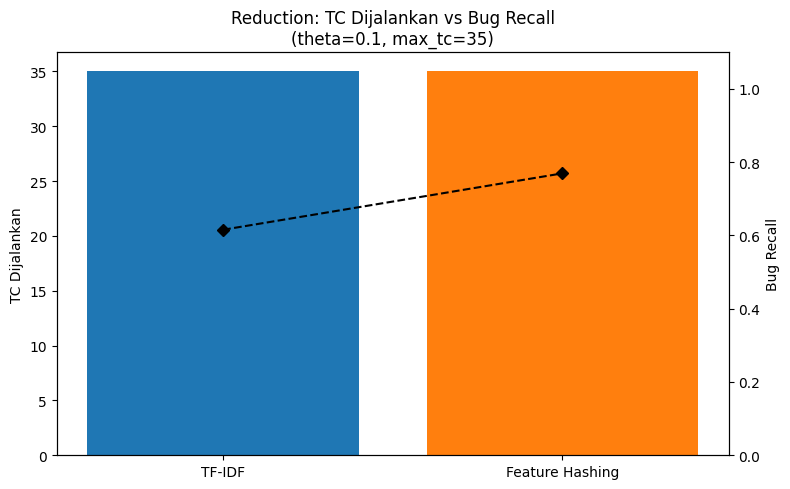

EXP1 CSV & JSON saved to results/


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import json, zipfile

os.makedirs("results", exist_ok=True)

summary_rows = []
for method, r in reduction_results.items():
    summary_rows.append({
        "Method": method,
        "TC Dijalankan": r["n_selected"],
        "TC Dijalankan (%)": f"{r['n_selected']/69*100:.1f}%",
        "Bug Recall": f"{r['bug_recall']:.1%}",
        "APFD": f"{r['apfd']:.1%}",
        "Bugs Found": r["bugs_found"],
        "Cost (menit)": f"{r['total_cost_min']:.0f}",
        "Stopped by theta": r["stopped_by_theta"]
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
df_summary.to_csv("results/exp1_vectorizer_summary.csv", index=False)
with open('results/exp1_reduction_results.json', 'w') as f:
    json.dump({k: {rk: (rv.tolist() if isinstance(rv, np.ndarray) else bool(rv) if isinstance(rv, (bool, np.bool_)) else int(rv) if isinstance(rv, (int, np.integer)) else float(rv) if isinstance(rv, (float, np.floating)) else rv) for rk, rv in v.items()} for k, v in reduction_results.items()}, f, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
methods = list(reduction_results.keys())
recalls = [reduction_results[m]["bug_recall"] for m in methods]
n_selected = [reduction_results[m]["n_selected"] for m in methods]
colors = sns.color_palette("tab10", len(methods))
bars = ax.bar(methods, n_selected, color=colors)
ax2 = ax.twinx()
ax2.plot(methods, recalls, "D--k", label="Bug Recall")
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Bug Recall")
ax.set_ylabel("TC Dijalankan")
ax.set_title(f"Reduction: TC Dijalankan vs Bug Recall\n(theta={STOP_THETA}, max_tc={MAX_TC})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("results/reduction_summary.png", dpi=100)
plt.show()
print("EXP1 CSV & JSON saved to results/")


## EXP2 — Does the similarity function (kernel) matter? (RQ2)

**Question:** cosine similarity is the default, but is it actually the best way to measure "how alike are these two test cases"? This tries four alternatives — RBF, Matern 3/2, Matern 5/2, and Rational Quadratic — all standard covariance functions from the Gaussian Process literature, each with a different assumption about how quickly similarity should fall off with distance.

**What happens in this cell:** same reduction loop, one representation held fixed (whichever came first in EXP1), kernel swapped each run.

EXP2: Kernel sweep using vectorizer 'TF-IDF'
  kernel=cosine    : 35 TC, recall=61.5%, APFD=32.9%
  kernel=rbf       : 35 TC, recall=53.8%, APFD=32.4%


  kernel=matern32  : 35 TC, recall=53.8%, APFD=32.2%
  kernel=matern52  : 35 TC, recall=53.8%, APFD=32.2%
  kernel=rq        : 35 TC, recall=53.8%, APFD=32.2%


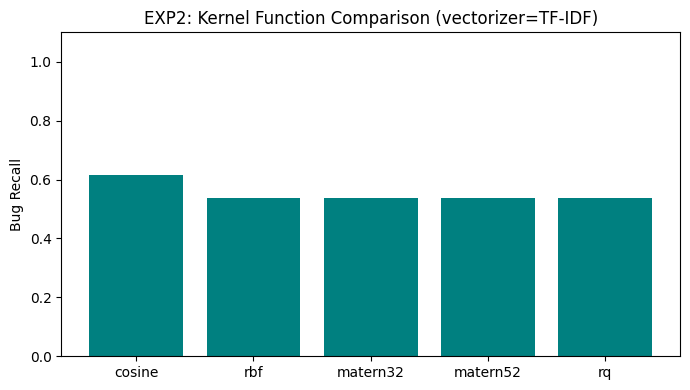

  kernel  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
  cosine      35    0.615385 0.328571         8.0     229.0             False
     rbf      35    0.538462 0.324176         7.0     218.0             False
matern32      35    0.538462 0.321978         7.0     218.0             False
matern52      35    0.538462 0.321978         7.0     218.0             False
      rq      35    0.538462 0.321978         7.0     218.0             False


In [10]:
KERNEL_OPTIONS = ['cosine', 'rbf', 'matern32', 'matern52', 'rq']
best_method = list(matrices.keys())[0]
best_matrix = matrices[best_method]
print(f"EXP2: Kernel sweep using vectorizer '{best_method}'")

kernel_results = []
for k_name in KERNEL_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=k_name, af_name=AF_NAME, hp_tuning=HP_TUNING, rng=np.random.default_rng(42)
    )
    kernel_results.append({
        "kernel": k_name,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  kernel={k_name:10s}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_kernel = pd.DataFrame(kernel_results)
df_kernel.to_csv("results/exp2_kernel_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_kernel["kernel"], df_kernel["bug_recall"], color="teal")
ax.set_ylabel("Bug Recall")
ax.set_ylim(0, 1.1)
ax.set_title(f"EXP2: Kernel Function Comparison (vectorizer={best_method})")
plt.tight_layout()
plt.savefig("results/exp2_kernel_sweep.png", dpi=100)
plt.show()
print(df_kernel.to_string(index=False))


## EXP3 — Is it worth tuning the kernel's hyperparameters? (RQ3)

**Question:** instead of using a fixed length-scale of 1.0, would letting the model estimate its own hyperparameters from the data (via Marginal Likelihood Estimation, optimized with L-BFGS-B) actually help, or is it not worth the extra computation?

**What happens in this cell:** the same loop runs twice — once with fixed hyperparameters, once re-tuning them at every step — and compares the outcomes.

In [11]:
best_method = list(matrices.keys())[0]
best_matrix = matrices[best_method]
HP_OPTIONS = ['fixed', 'mle']
print(f"EXP3: HP Tuning sweep using vectorizer '{best_method}'")

hp_results = []
for hp_mode in HP_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME, af_name=AF_NAME, hp_tuning=hp_mode, rng=np.random.default_rng(42)
    )
    hp_results.append({
        "hp_tuning": hp_mode,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  hp_tuning={hp_mode:8s}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_hp = pd.DataFrame(hp_results)
df_hp.to_csv("results/exp3_hp_tuning_sweep.csv", index=False)
print(df_hp.to_string(index=False))


EXP3: HP Tuning sweep using vectorizer 'TF-IDF'
  hp_tuning=fixed   : 35 TC, recall=61.5%, APFD=32.9%


  hp_tuning=mle     : 35 TC, recall=53.8%, APFD=32.6%
hp_tuning  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
    fixed      35    0.615385 0.328571         8.0     229.0             False
      mle      35    0.538462 0.326374         7.0     224.0             False


## EXP4 — Which rule for picking the next test case works best? (RQ4)

**Question:** Cost-UCB is the default acquisition rule, but there are five other standard choices from the Bayesian optimization literature: Expected Improvement (EI), a numerically safer version of it (LogEI), plain UCB (no cost adjustment), Probability of Improvement (PI), and Thompson Sampling. Which one actually finds bugs fastest for this kind of problem?

**What happens in this cell:** same setup, acquisition rule swapped each run.

EXP4: Acquisition function sweep using vectorizer 'TF-IDF'
  af=cost_ucb  : 35 TC, recall=61.5%, APFD=32.9%
  af=ei        : 35 TC, recall=76.9%, APFD=42.5%
  af=logei     : 35 TC, recall=76.9%, APFD=42.5%
  af=ucb       : 35 TC, recall=76.9%, APFD=41.4%
  af=pi        : 35 TC, recall=76.9%, APFD=42.5%
  af=ts        : 35 TC, recall=76.9%, APFD=35.7%


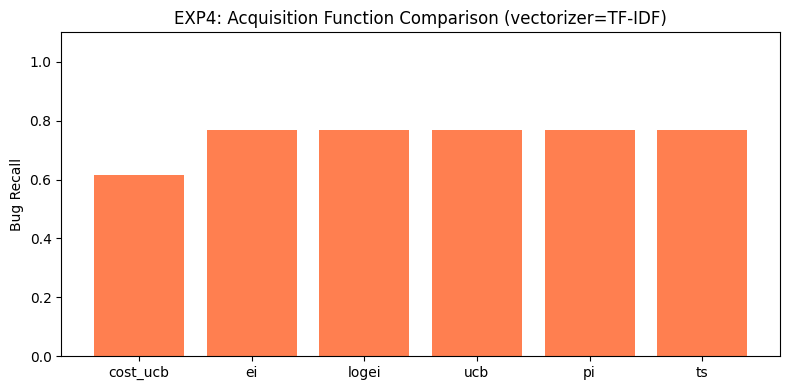

acquisition_fn  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
      cost_ucb      35    0.615385 0.328571         8.0     229.0             False
            ei      35    0.769231 0.425275        10.0     309.0             False
         logei      35    0.769231 0.425275        10.0     309.0             False
           ucb      35    0.769231 0.414286        10.0     309.0             False
            pi      35    0.769231 0.425275        10.0     309.0             False
            ts      35    0.769231 0.357143        10.0     326.0             False


In [12]:
best_method = list(matrices.keys())[0]
best_matrix = matrices[best_method]
AF_OPTIONS = ['cost_ucb', 'ei', 'logei', 'ucb', 'pi', 'ts']
print(f"EXP4: Acquisition function sweep using vectorizer '{best_method}'")

af_results = []
for af_opt in AF_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME, af_name=af_opt, hp_tuning=HP_TUNING, rng=np.random.default_rng(42)
    )
    af_results.append({
        "acquisition_fn": af_opt,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  af={af_opt:10s}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_af = pd.DataFrame(af_results)
df_af.to_csv("results/exp4_af_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_af["acquisition_fn"], df_af["bug_recall"], color="coral")
ax.set_ylabel("Bug Recall")
ax.set_ylim(0, 1.1)
ax.set_title(f"EXP4: Acquisition Function Comparison (vectorizer={best_method})")
plt.tight_layout()
plt.savefig("results/exp4_af_sweep.png", dpi=100)
plt.show()
print(df_af.to_string(index=False))


## EXP5 — How much should UCB favor exploring the unknown? (RQ5)

**Question:** UCB's behavior is controlled by one knob, beta — a higher value makes it chase uncertain/unfamiliar test cases more; a lower value makes it stick closer to what looks risky based on what's already been seen. This sweeps beta across {1.0, 2.0, 3.0, 4.0} to see where that trade-off lands best.

**A bug fix that landed here:** in earlier runs, changing beta in this sweep had no effect on which test cases actually got picked — the value never reached the acquisition function (see Step 3's note on the stopping-rule fix for the full explanation). That's fixed now, so the numbers below reflect beta actually being varied, not four identical runs.

In [13]:
best_method = list(matrices.keys())[0]
best_matrix = matrices[best_method]
BETA_OPTIONS = [1.0, 2.0, 3.0, 4.0]
print(f"EXP5: Beta sweep using vectorizer '{best_method}'")

beta_results = []
for b_val in BETA_OPTIONS:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME, af_name="ucb", hp_tuning=HP_TUNING, beta=b_val, rng=np.random.default_rng(42)
    )
    beta_results.append({
        "beta": b_val,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  beta={b_val:.1f}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_beta = pd.DataFrame(beta_results)
df_beta.to_csv("results/exp5_beta_sweep.csv", index=False)
print(df_beta.to_string(index=False))


EXP5: Beta sweep using vectorizer 'TF-IDF'
  beta=1.0: 35 TC, recall=76.9%, APFD=42.5%
  beta=2.0: 35 TC, recall=76.9%, APFD=41.4%
  beta=3.0: 35 TC, recall=76.9%, APFD=43.0%
  beta=4.0: 35 TC, recall=76.9%, APFD=42.3%
 beta  TC_run  bug_recall     apfd  bugs_found  cost_min  stopped_by_theta
  1.0      35    0.769231 0.425275        10.0     309.0             False
  2.0      35    0.769231 0.414286        10.0     309.0             False
  3.0      35    0.769231 0.429670        10.0     312.0             False
  4.0      35    0.769231 0.423077        10.0     305.0             False


## EXP6 — How sensitive is the stopping point to theta? (RQ6)

**Question:** the model stops early only once it's confident about *every* remaining test case, not just the average one — the upper bound of the LEAST certain candidate still has to clear theta. A stricter theta should mean running more tests before that happens; a looser one should reach it sooner. This sweeps theta across {0.50, 0.52, 0.53, 0.55} to show that trade-off directly, in the chart below.

**Why this range and not {0.05, 0.1, 0.2, 0.3} like before:** because the rule needs ALL remaining candidates below theta, it's bottlenecked by whichever single test case the model is currently least sure about -- and on this dataset that stays stubbornly in the 0.5-0.6 range for most of the run, regardless of how many test cases have already been checked. Every theta below roughly 0.5 behaves identically (full 35-TC budget, never stops) -- that floor, not a leftover bug, is why the old {0.05, 0.1, 0.2, 0.3} sweep always looked flat, even after the beta fix in Step 3. The actual sensitivity all happens in a narrow band just above that floor: on the numbers this notebook produces, theta=0.50 never stops (35 of 35 TC), 0.52 stops after 29, 0.53 after just 11, and 0.55 stops almost immediately at the 9-TC warm start. That's a sharp threshold rather than a smooth ramp -- it only takes ONE stubborn remaining test case to keep the model from stopping, so crossing that one candidate's confidence level flips the outcome fast.

EXP6: theta sweep menggunakan vectorizer 'TF-IDF'
  theta=0.5: 35 TC, recall=61.5%
  theta=0.52: 29 TC, recall=53.8%
  theta=0.53: 11 TC, recall=15.4%
  theta=0.55: 10 TC, recall=15.4%


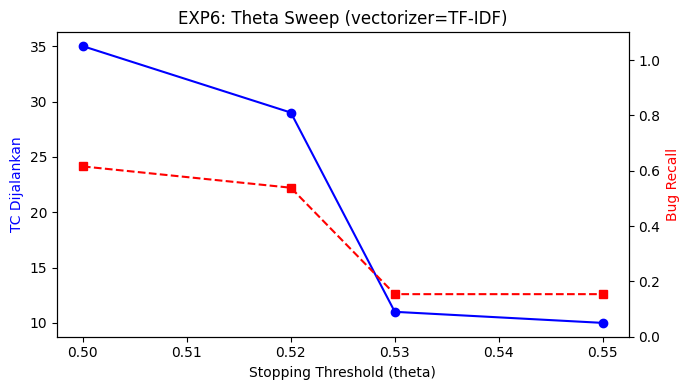

 theta  TC_run  bug_recall  bugs_found  cost_min  stopped_by_theta
  0.50      35    0.615385         8.0     229.0             False
  0.52      29    0.538462         7.0     173.0              True
  0.53      11    0.153846         2.0      75.0              True
  0.55      10    0.153846         2.0      73.0              True


In [14]:
THETA_VALUES = [0.50, 0.52, 0.53, 0.55]

best_method = list(matrices.keys())[0]
best_matrix = matrices[best_method]
print(f"EXP6: theta sweep menggunakan vectorizer '{best_method}'")

theta_results = []
for theta in THETA_VALUES:
    r = run_reduction_loop(
        matrix=best_matrix,
        ids=ids,
        menus=menus,
        costs=costs,
        oracle=oracle,
        initial_indices=initial_indices,
        max_tc=MAX_TC,
        stop_theta=theta,
        kernel_name=KERNEL_NAME,
        af_name=AF_NAME,
        rng=np.random.default_rng(42)
    )
    theta_results.append({
        "theta": theta,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"],
        "stopped_by_theta": r["stopped_by_theta"]
    })
    print(f"  theta={theta}: {r['n_selected']} TC, recall={r['bug_recall']:.1%}")

df_theta = pd.DataFrame(theta_results)
df_theta.to_csv("results/exp6_theta_sweep.csv", index=False)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(df_theta["theta"], df_theta["TC_run"], "o-b", label="TC Dijalankan")
ax1.set_xlabel("Stopping Threshold (theta)")
ax1.set_ylabel("TC Dijalankan", color="b")
ax2 = ax1.twinx()
ax2.plot(df_theta["theta"], df_theta["bug_recall"], "s--r", label="Bug Recall")
ax2.set_ylabel("Bug Recall", color="r")
ax2.set_ylim(0, 1.1)
ax1.set_title(f"EXP6: Theta Sweep (vectorizer={best_method})")
plt.tight_layout()
plt.savefig("results/exp6_theta_sweep.png", dpi=100)
plt.show()
print(df_theta.to_string(index=False))


## EXP7 — How much better is this than just picking test cases at random? (RQ7)

**Question:** if QA genuinely can't run all 69 and has to pick a fixed number in advance — 20, 30, 40, or 50 — does the Bayesian approach actually beat just grabbing that many test cases at random? This is the most important sanity check in the notebook: a smart-looking method that doesn't clearly beat random selection isn't worth the added complexity.

**What happens in this cell:** the reduction loop runs once per budget size, and is compared against the *average* of 20 independent random selections at each of those same budget sizes — one random draw could get lucky or unlucky, so averaging over 20 gives a fair baseline.

EXP7: Budget sweep using vectorizer 'TF-IDF'
  max_tc=20: ran 20 TC, recall=53.8%, APFD=16.7%
  max_tc=30: ran 30 TC, recall=53.8%, APFD=29.1%
  max_tc=40: ran 40 TC, recall=69.2%, APFD=37.2%
  max_tc=50: ran 50 TC, recall=92.3%, APFD=47.0%


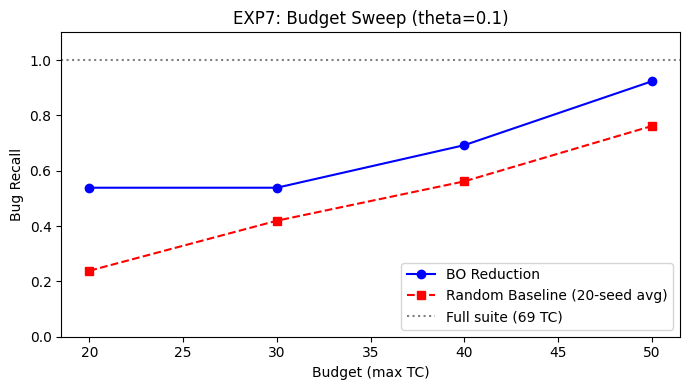

 max_tc  TC_run  bug_recall     apfd  bugs_found  cost_min
     20      20    0.538462 0.167308         7.0     107.0
     30      30    0.538462 0.291026         7.0     182.0
     40      40    0.692308 0.372115         9.0     285.0
     50      50    0.923077 0.470000        12.0     397.0


In [15]:
best_method = list(matrices.keys())[0]
best_matrix = matrices[best_method]
BUDGET_VALUES = [20, 30, 40, 50]

print(f"EXP7: Budget sweep using vectorizer '{best_method}'")

budget_results = []
for max_tc in BUDGET_VALUES:
    r = run_reduction_loop(
        matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle,
        initial_indices=initial_indices,
        max_tc=max_tc,
        stop_theta=STOP_THETA,
        kernel_name=KERNEL_NAME,
        af_name=AF_NAME,
        rng=np.random.default_rng(42)
    )
    budget_results.append({
        "max_tc": max_tc,
        "TC_run": r["n_selected"],
        "bug_recall": r["bug_recall"],
        "apfd": r["apfd"],
        "bugs_found": r["bugs_found"],
        "cost_min": r["total_cost_min"]
    })
    print(f"  max_tc={max_tc}: ran {r['n_selected']} TC, recall={r['bug_recall']:.1%}, APFD={r['apfd']:.1%}")

df_budget = pd.DataFrame(budget_results)
df_budget.to_csv("results/exp7_budget_sweep.csv", index=False)

random_recalls = []
rng_base = np.random.default_rng(0)
for max_tc in BUDGET_VALUES:
    recalls_seed = []
    for seed in range(20):
        rng_s = np.random.default_rng(seed)
        idx = rng_s.choice(69, size=max_tc, replace=False)
        recalls_seed.append(oracle[idx].sum() / oracle.sum())
    random_recalls.append(np.mean(recalls_seed))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_budget["max_tc"], df_budget["bug_recall"], "o-b", label="BO Reduction")
ax.plot(BUDGET_VALUES, random_recalls, "s--r", label="Random Baseline (20-seed avg)")
ax.axhline(1.0, color="gray", linestyle=":", label="Full suite (69 TC)")
ax.set_xlabel("Budget (max TC)")
ax.set_ylabel("Bug Recall")
ax.set_ylim(0, 1.1)
ax.set_title(f"EXP7: Budget Sweep (theta={STOP_THETA})")
ax.legend()
plt.tight_layout()
plt.savefig("results/exp7_budget_sweep.png", dpi=100)
plt.show()
print(df_budget.to_string(index=False))


## EXP8 — Do the results above collapse without content-correlation? (RQ8)

**Question:** EXP1-EXP7 above all use the same fixed oracle where the 13 dummy bugs are concentrated in a couple of risky Menus (see Step 1). Is that concentration actually what's driving any advantage seen above, or would text-similarity-based selection do just as well against bugs that have nothing to do with test-case content?

**What happens in this cell:** 10 independent replicates, each with a completely uniform-random placement of 13 dummy bugs (the same fully-scattered, content-independent style this notebook used before the oracle was fixed), run through every representation. No single "winner" is declared here on purpose — this section exists to stress-test the earlier results, not to produce a new leaderboard.

**What to expect:** if content-correlation is really what matters, the mean recall here should land back down near chance level, clearly below EXP1-EXP7's numbers — the opposite of what EXP1-EXP7 showed with the clustered oracle.


In [16]:
def draw_uniform_oracle(case_count, bug_count, random_state):
    rng_f = np.random.default_rng(random_state)
    oracle_f = np.zeros(case_count)
    idx = rng_f.choice(case_count, size=bug_count, replace=False)
    oracle_f[idx] = 1.0
    return oracle_f

print("=== EXP8: EXECUTING FAIRNESS CHECK ACROSS 10 SYNTHETIC BUG ORACLES ===\n")
fairness_rows = []
for method_name, matrix in matrices.items():
    for rep in range(N_FAIRNESS_REPLICATES):
        oracle_f = draw_uniform_oracle(69, 13, rep)
        r = run_reduction_loop(
            matrix=matrix,
            ids=ids,
            menus=menus,
            costs=costs,
            oracle=oracle_f,
            initial_indices=initial_indices,
            max_tc=MAX_TC,
            stop_theta=STOP_THETA,
            kernel_name=KERNEL_NAME,
            af_name=AF_NAME,
            rng=np.random.default_rng(rep)
        )
        fairness_rows.append({
            "method": method_name,
            "rep": rep,
            "n_selected": r["n_selected"],
            "bug_recall": r["bug_recall"],
            "bugs_found": r["bugs_found"]
        })

df_fairness = pd.DataFrame(fairness_rows)
df_fair_summary = df_fairness.groupby("method").agg(
    mean_recall=("bug_recall", "mean"),
    std_recall=("bug_recall", "std"),
    mean_bugs=("bugs_found", "mean"),
    mean_tc=("n_selected", "mean")
).round(3)

print("=== EXP8 FAIRNESS SUMMARY TABLE (10 REPLICATES PER METHOD) ===")
print(df_fair_summary.to_string())

os.makedirs("results", exist_ok=True)
df_fairness.to_csv("results/fairness_reduction.csv", index=False)
df_fair_summary.to_csv("results/fairness_reduction_summary.csv")
print("\nSaved fairness_reduction.csv and fairness_reduction_summary.csv to results/")


=== EXP8: EXECUTING FAIRNESS CHECK ACROSS 10 SYNTHETIC BUG ORACLES ===



=== EXP8 FAIRNESS SUMMARY TABLE (10 REPLICATES PER METHOD) ===
                 mean_recall  std_recall  mean_bugs  mean_tc
method                                                      
Feature Hashing        0.408       0.150        5.3     35.0
TF-IDF                 0.423       0.151        5.5     35.0

Saved fairness_reduction.csv and fairness_reduction_summary.csv to results/


## EXP9 — Is the EXP1-EXP7 advantage robust to which Menus are "risky"? (RQ9)

**Why this exists:** EXP1-EXP7 above use ONE fixed clustered oracle — 13 dummy bugs concentrated in whichever 2 Menus were drawn as "risky" in Step 1. EXP8 already showed that removing the content-correlation collapses the advantage back toward chance. This section checks the other direction: is the advantage specific to *those two Menus* happening to be easy for text similarity to separate, or does it show up for pretty much any random choice of 2 risky Menus?

**What happens in this cell:** 10 independent replicates, each with a *fresh* random choice of which Menus are "risky" (reusing `draw_clustered_oracle` from Step 1, just with a different seed each time), run through every representation. If the method is doing something real rather than exploiting one lucky Menu pairing, the recall here should land close to EXP1-EXP7's numbers on average, and clearly above EXP8's scattered/uncorrelated baseline.


In [17]:
N_CLUSTERED_REPLICATES = int(os.getenv("BO_CLUSTERED_REPS", "10"))

print("=== EXP9: EXECUTING CLUSTERED (CONTENT-CORRELATED) BUG ORACLE ROBUSTNESS CHECK ===\n")
clustered_rows = []
for method_name, matrix in matrices.items():
    for rep in range(N_CLUSTERED_REPLICATES):
        oracle_c, risky_menus = draw_clustered_oracle(
            cases, bug_count=13, n_risky_menus=N_RISKY_MENUS, random_state=rep
        )
        r = run_reduction_loop(
            matrix=matrix, ids=ids, menus=menus, costs=costs, oracle=oracle_c,
            initial_indices=initial_indices, max_tc=MAX_TC, stop_theta=STOP_THETA,
            kernel_name=KERNEL_NAME, af_name=AF_NAME, rng=np.random.default_rng(rep)
        )
        clustered_rows.append({
            "method": method_name,
            "rep": rep,
            "risky_menus": ", ".join(map(str, risky_menus)),
            "n_selected": r["n_selected"],
            "bug_recall": r["bug_recall"],
            "bugs_found": r["bugs_found"],
        })

df_clustered = pd.DataFrame(clustered_rows)
df_clustered_summary = df_clustered.groupby("method").agg(
    mean_recall=("bug_recall", "mean"),
    std_recall=("bug_recall", "std"),
    mean_bugs=("bugs_found", "mean"),
    mean_tc=("n_selected", "mean"),
).round(3)

print("=== EXP9 CLUSTERED-ORACLE SUMMARY TABLE (10 REPLICATES, DIFFERENT RISKY MENUS EACH TIME) ===")
print(df_clustered_summary.to_string())

print(f"\nFor comparison, EXP1's single fixed default oracle (risky menus: {list(map(str, RISKY_MENUS))}):")
for m, r in reduction_results.items():
    print(f"  {m:32s}: recall={r['bug_recall']:.1%}")

print("\nAnd EXP8's content-independent (uniform-random) oracle:")
print(df_fair_summary.to_string())

os.makedirs("results", exist_ok=True)
df_clustered.to_csv("results/clustered_oracle_reduction.csv", index=False)
df_clustered_summary.to_csv("results/clustered_oracle_reduction_summary.csv")
print("\nSaved clustered_oracle_reduction.csv and clustered_oracle_reduction_summary.csv to results/")


=== EXP9: EXECUTING CLUSTERED (CONTENT-CORRELATED) BUG ORACLE ROBUSTNESS CHECK ===



=== EXP9 CLUSTERED-ORACLE SUMMARY TABLE (10 REPLICATES, DIFFERENT RISKY MENUS EACH TIME) ===
                 mean_recall  std_recall  mean_bugs  mean_tc
method                                                      
Feature Hashing        0.731       0.104        9.5     35.0
TF-IDF                 0.669       0.089        8.7     35.0

For comparison, EXP1's single fixed default oracle (risky menus: ['Buat Chat Baru', 'Profil Pengguna']):
  TF-IDF                          : recall=61.5%
  Feature Hashing                 : recall=76.9%

And EXP8's content-independent (uniform-random) oracle:
                 mean_recall  std_recall  mean_bugs  mean_tc
method                                                      
Feature Hashing        0.408       0.150        5.3     35.0
TF-IDF                 0.423       0.151        5.5     35.0

Saved clustered_oracle_reduction.csv and clustered_oracle_reduction_summary.csv to results/


### EXP9b — Budget sweep, averaged across different risky-Menu choices

EXP7 above already shows the budget-vs-recall curve for the default clustered oracle (from Step 1). This repeats that sweep, but averaged over the same 10 different risky-Menu draws used in EXP9, so the curve reflects the typical case rather than one specific choice of risky Menus — with error bars showing how much that curve moves around depending on which Menus turned out to be risky.


EXP9b: Budget sweep averaged across 10 different clustered-oracle draws, vectorizer='TF-IDF'
  max_tc=20: BO mean recall=38.5% (+/-10.9%), random mean=29.8%
  max_tc=30: BO mean recall=54.6% (+/-8.0%), random mean=43.9%


  max_tc=40: BO mean recall=76.2% (+/-11.1%), random mean=56.8%


  max_tc=50: BO mean recall=85.4% (+/-11.1%), random mean=70.2%


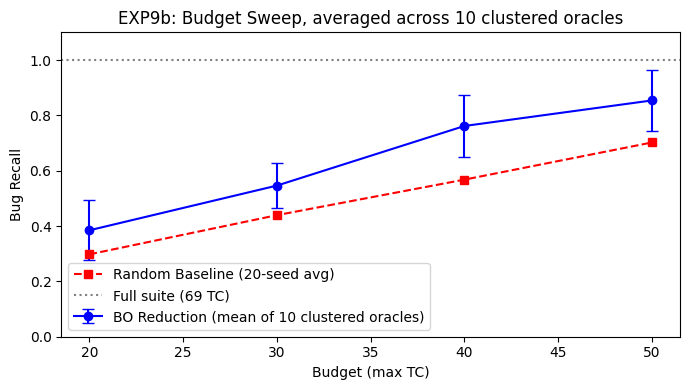

 max_tc  bo_mean_recall  bo_std_recall  random_mean_recall
     20        0.384615       0.108786            0.297692
     30        0.546154       0.080310            0.439231
     40        0.761538       0.111206            0.567692
     50        0.853846       0.111206            0.701923

EXP9 + EXP9b results saved to results/


In [18]:
best_method = list(matrices.keys())[0]
best_matrix = matrices[best_method]
BUDGET_VALUES = [20, 30, 40, 50]

print(f"EXP9b: Budget sweep averaged across {N_CLUSTERED_REPLICATES} different clustered-oracle draws, vectorizer='{best_method}'")

clustered_budget_rows = []
for max_tc in BUDGET_VALUES:
    recalls_this_budget = []
    random_recalls_this_budget = []
    for rep in range(N_CLUSTERED_REPLICATES):
        oracle_rep, risky_menus_rep = draw_clustered_oracle(
            cases, bug_count=13, n_risky_menus=N_RISKY_MENUS, random_state=rep
        )
        r = run_reduction_loop(
            matrix=best_matrix, ids=ids, menus=menus, costs=costs, oracle=oracle_rep,
            initial_indices=initial_indices,
            max_tc=max_tc,
            stop_theta=STOP_THETA,
            kernel_name=KERNEL_NAME,
            af_name=AF_NAME,
            rng=np.random.default_rng(rep)
        )
        recalls_this_budget.append(r["bug_recall"])

        # Random baseline for this SAME oracle draw, so BO and random are
        # compared fairly against an identical bug placement each time.
        seed_recalls = []
        for seed in range(20):
            rng_s = np.random.default_rng(seed)
            idx = rng_s.choice(69, size=max_tc, replace=False)
            seed_recalls.append(oracle_rep[idx].sum() / oracle_rep.sum())
        random_recalls_this_budget.append(np.mean(seed_recalls))

    clustered_budget_rows.append({
        "max_tc": max_tc,
        "bo_mean_recall": np.mean(recalls_this_budget),
        "bo_std_recall": np.std(recalls_this_budget),
        "random_mean_recall": np.mean(random_recalls_this_budget),
    })
    print(f"  max_tc={max_tc}: BO mean recall={np.mean(recalls_this_budget):.1%} "
          f"(+/-{np.std(recalls_this_budget):.1%}), random mean={np.mean(random_recalls_this_budget):.1%}")

df_cbudget = pd.DataFrame(clustered_budget_rows)
df_cbudget.to_csv("results/clustered_oracle_budget_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(df_cbudget["max_tc"], df_cbudget["bo_mean_recall"], yerr=df_cbudget["bo_std_recall"],
            fmt="o-b", capsize=4, label=f"BO Reduction (mean of {N_CLUSTERED_REPLICATES} clustered oracles)")
ax.plot(df_cbudget["max_tc"], df_cbudget["random_mean_recall"], "s--r", label="Random Baseline (20-seed avg)")
ax.axhline(1.0, color="gray", linestyle=":", label="Full suite (69 TC)")
ax.set_xlabel("Budget (max TC)")
ax.set_ylabel("Bug Recall")
ax.set_ylim(0, 1.1)
ax.set_title(f"EXP9b: Budget Sweep, averaged across {N_CLUSTERED_REPLICATES} clustered oracles")
ax.legend()
plt.tight_layout()
plt.savefig("results/clustered_oracle_budget_sweep.png", dpi=100)
plt.show()
print(df_cbudget.to_string(index=False))
print("\nEXP9 + EXP9b results saved to results/")


## How to read all of this

Each EXP section above answers one narrow question in isolation, with everything else held fixed at its default. None of them, alone or together, prove which real-world setting is "best" — they show how the model *behaves* under each choice, on one synthetic, controlled scenario.

EXP1-EXP7 now use a single fixed oracle where the 13 dummy bugs are deliberately concentrated in a couple of "risky" Menus (see Step 1) rather than spread thin across all of them — mirroring how real bugs tend to cluster in specific, complex or recently-changed features rather than appearing everywhere uniformly. EXP8 is the negative control: it reruns everything against a fully scattered, content-independent bug placement (10 replicates) to confirm any advantage above isn't just noise. EXP9 is the robustness check in the other direction: 10 replicates with a fresh random choice of which Menus are risky, to confirm the advantage isn't a fluke of the two Menus picked for the default oracle, and EXP9b repeats EXP7's budget sweep the same way. Read EXP1-EXP7 as "does this work when there IS a real pattern to find," EXP8 as "does it correctly stop working when that pattern is removed," and EXP9/EXP9b as "does it keep working across many different versions of that pattern" — all three are needed together before spending real QA time and API budget on this pipeline against real execution outcomes (see the reduction folder's `README.md` for what that next step needs).


## Packaging everything up

Bundles every CSV, JSON, and PNG produced above into one zip file, so the full EXP1-EXP9 run can be handed off or archived in one piece.

In [19]:
import zipfile
from pathlib import Path

results_dir = Path("results")
zip_path = Path("reduction_experiment_results.zip")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in results_dir.glob('*'):
        if file.is_file():
            zipf.write(file, arcname=file.name)
            print(f"Zipped: {file.name}")

print(f"\nAll EXP1-EXP9 logs, CSVs, JSONs, and PNGs packaged into: {zip_path.resolve()}")


Zipped: clustered_oracle_reduction.csv
Zipped: exp1_vectorizer_summary.csv
Zipped: exp4_af_sweep.png
Zipped: exp5_beta_sweep.csv
Zipped: clustered_oracle_reduction_summary.csv
Zipped: clustered_oracle_budget_sweep.csv
Zipped: exp6_theta_sweep.png
Zipped: exp7_budget_sweep.csv
Zipped: exp6_theta_sweep.csv
Zipped: fairness_reduction_summary.csv
Zipped: clustered_oracle_budget_sweep.png
Zipped: reduction_summary.png
Zipped: exp2_kernel_sweep.png
Zipped: exp4_af_sweep.csv
Zipped: exp3_hp_tuning_sweep.csv
Zipped: fairness_reduction.csv
Zipped: exp2_kernel_sweep.csv
Zipped: exp7_budget_sweep.png
Zipped: exp1_reduction_results.json

All EXP1-EXP9 logs, CSVs, JSONs, and PNGs packaged into: /mnt/user-data/uploads/MAS AI/experiment/bayesian/reduction/reduction_experiment_results.zip
